In [1]:
import pandas as pd
from collections import defaultdict
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv('datasets/arxiv34k6L.csv', engine='python', on_bad_lines='warn')

# Answer Question 1 - 5

**1.ชื่อหัวข้อ** : ArXiv Multi-Label Text Classification Datasets

**2.อธิบายปัญหา** : เนื่องจากในการจำแนกข้อมูลที่เป็นข้อความ โดยเฉพาะการวิเคราะห์ข้อมูลที่มีหัวข้อแยกย่อยจากหัวข้อใหญ่ เช่น
* ปัญหาการร้องเรียน โดยการแยกเพียงแค่หมวดหมู่อย่างเดียวอาจจะไม่พอ เนื่องจากในหมวดหมู่การร้องเรียนอาจจะมีหมวดหมู่แยกย่อย (Hierarchical) ทำให้ข้อมูลนั้นไม่ถูกแยกแบบถูกต้อง
* ระบบ IT Support โดยจะมีหมวดหมู่หลัก เช่น Network issue และในหมวดหมู่หลักนั้นก็จะมีหมวดหมู่ที่ย่อยลงไป VPN, Wifi เป็นต้น

จากปัญหาข้างต้นที่ยกตัวอย่างมา จะเห็นได้ว่าข้อมูลนั้นมีความซับซ้อนและมีลักษณะของข้อมูลที่ล้นเกินไป ทำให้การจำแนกหมวดหมู่หลักเพียงอย่างเดียวอาจจะไม่พอ และไม่มีประสิทธิภาพในการนำไปใช้งานจริงที่ดีพอ

ดังนั้นการแก้ปัญหาดังกล่าวจะช่วยให้มีประโยชน์เรื่องการจัดลำดับความสำคัญ และการจัดการข้อมูลเพื่อนำไปใช้ประโยชน์

**3.Dataset** : ArXiv Multi-Label Text Classification Datasets (เลือก arxiv34k6L.csv)

**Links** : https://www.kaggle.com/datasets/kelixirr/arxiv-multi-label-text-classification-datasets/code

**4.จำนวนคลาสที่ทำนาย** : ในชุดข้อมูลนี้มี Parent ทั้งหมด 2 class ได้แก่ CS, Stat และแต่ละ Parent จะมี Child (leaf) ของตัวเอง ดังนี้


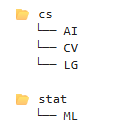

ทำให้เมื่อพิจารณาทำเป็น Hierarchical Classification จริง ๆ คือจะต้องทำนายเป็น 2 ขั้น คือ


1.   ทำนายว่าเป็น CS, Stat
2.   แล้วค่อยทำนาย Chlid ของแต่ละ Parent

แบบนี้โครงสร้างรวมมี 4 leaf classes (Target)
แต่โมเดลจะเรียนรู้แบบลำดับชั้น

**5.ระบุคอลัมน์ที่ใช้เป็น input และ output** :
* input : Abstracts
* output : Categories


# Answer Question 6 - 7

In [8]:
label_column = "categories"

# แปลง string list → list จริง
df[label_column] = df[label_column].apply(ast.literal_eval)

**6.แสดงข้อมูลตัวอย่างของทุกคลาส พร้อมทั้งระบุข้อมูลเข้า (input) และข้อมูลออก (output) ให้สอดคล้องกับข้อมูล**

In [11]:
all_labels = set()

for label_list in df["categories"]:
    for label in label_list:
        all_labels.add(label)

print("Total unique leaf classes:", len(all_labels))
print("Total samples:", len(df))

print("\n=== Example per class (RAW) ===\n")

for cls in sorted(all_labels):
    sample_row = df[df["categories"].apply(lambda x: cls in x)].iloc[0]

    print("--------------------------------------------------")
    print("Class:", cls)
    print("Input (abstract):\n", sample_row["Abstracts"][:300])
    print("Output (labels):", sample_row["categories"])
    print("--------------------------------------------------\n")

Total unique leaf classes: 4
Total samples: 34068

=== Example per class (RAW) ===

--------------------------------------------------
Class: cs.AI
Input (abstract):
 Traditional supervised learning methods have historically encountered certain
constraints in medical image segmentation due to the challenging collection
process, high labeling cost, low signal-to-noise ratio, and complex features
characterizing biomedical images. This paper proposes a semi-supervis
Output (labels): ['cs.CV', 'cs.AI']
--------------------------------------------------

--------------------------------------------------
Class: cs.CV
Input (abstract):
 Reusing features in deep networks through dense connectivity is an effective
way to achieve high computational efficiency. The recent proposed CondenseNet
has shown that this mechanism can be further improved if redundant features are
removed. In this paper, we propose an alternative approach named 
Output (labels): ['cs.CV']
---------------------------------

**7.วิเคราะห์ข้อมูลสถิติที่สำคัญเกี่ยวกับ dataset และอธิบายความหมาย**


*   ไม่น้อยกว่า 10 ข้อมูลสถิติ
*   แสดงในรูปแบบกราฟ (กรณีที่ค่าทางสถิติสามารถแสดงได้)



ตรวจสอบ Missing Values

In [19]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
Abstracts     0
categories    0
dtype: int64


**7.1.Class Distribution**

categories
[cs.LG]             8140
[cs.CV]             8051
[cs.LG, cs.AI]      6134
[cs.LG, stat.ML]    4266
[cs.CV, cs.AI]      3818
[cs.CV, cs.LG]      3659
Name: count, dtype: int64


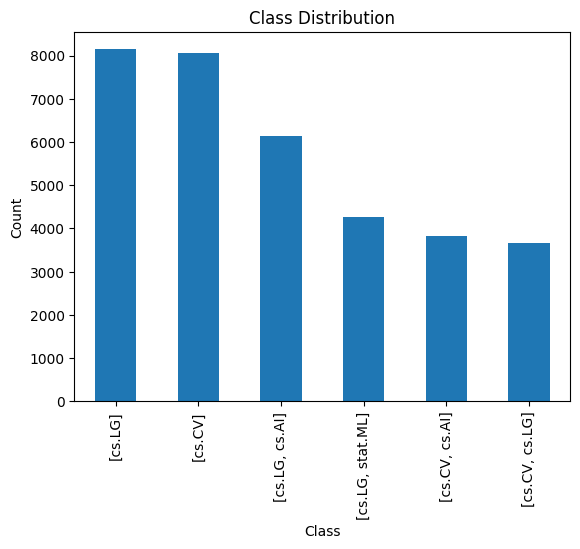

categories
[cs.LG]             23.893390
[cs.CV]             23.632147
[cs.LG, cs.AI]      18.005166
[cs.LG, stat.ML]    12.522015
[cs.CV, cs.AI]      11.206998
[cs.CV, cs.LG]      10.740284
Name: proportion, dtype: float64


In [17]:
print(df['categories'].value_counts())

plt.figure()
df['categories'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ดูเป็น %
print(df['categories'].value_counts(normalize=True) * 100)

ชุดข้อมูลนี้เน้นไปที่ Machine Learning ([cs.LG]) และ Computer Vision ([cs.CV]) เป็นหลัก โดยสองกลุ่มนี้มีสัดส่วนรวมกันเกือบครึ่งหนึ่งของทั้งหมด (ประมาณ 48%) นอกจากนี้ Multi-label ของเนื้อหาที่มักปรากฏคู่กับ AI และ Statistics อย่างชัดเจน

**7.2.Class distribution (Each class)**

In [ ]:
def split_labels(label_list):
    new_labels = []
    for label in label_list:
        if "," in label:
            parts = label.split(",")
            for p in parts:
                new_labels.append(p.strip())
        else:
            new_labels.append(label.strip())
    return new_labels

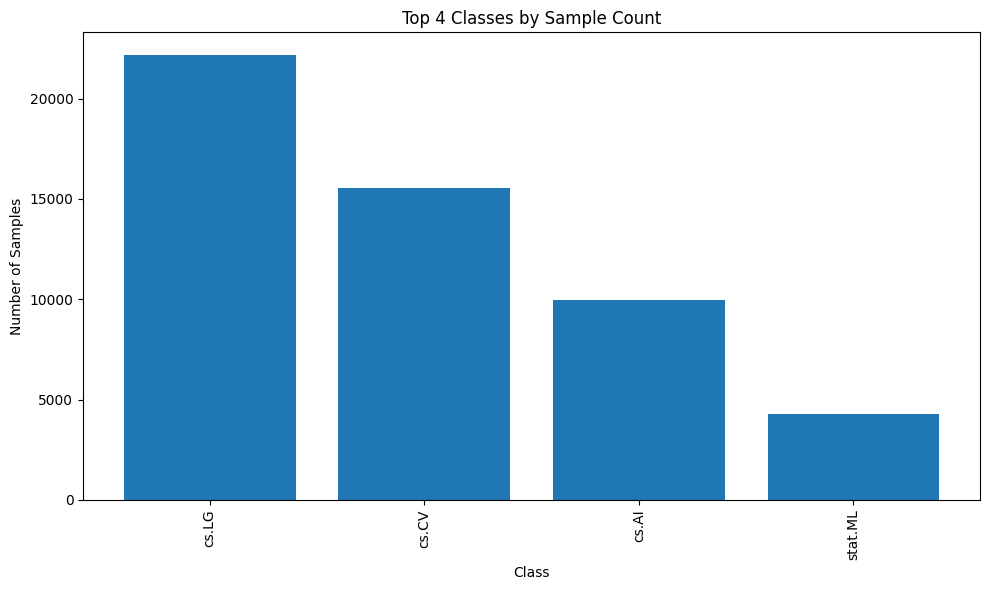

In [24]:
df["clean_labels"] = df["categories"].apply(split_labels)


all_labels = []
for labels in df["clean_labels"]:
    all_labels.extend(labels)

label_counts = pd.Series(all_labels).value_counts()

top_n = 4
top_classes = label_counts.head(top_n)

plt.figure(figsize=(10,6))
plt.bar(top_classes.index, top_classes.values)
plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Top 4 Classes by Sample Count")
plt.tight_layout()
plt.show()

กราฟนี้แสดงให้เห็นว่าข้อมูลส่วนใหญ่เทไปที่หมวด Machine Learning (cs.LG) ซึ่งมีจำนวนตัวอย่างสูงที่สุด (มากกว่า 20,000 รายการ) ตามมาด้วย Computer Vision (cs.CV) และ Artificial Intelligence (cs.AI) ในขณะที่ Statistics (stat.ML) มีสัดส่วนน้อยที่สุดในบรรดา Top 4 สะท้อนถึงปัญหา Class Imbalance ที่ค่อนข้างชัดเจน

**7.3.ตรวจดูสถิติการกระจายของข้อมูล**

In [23]:
print("Total unique classes:", len(label_counts))
print("\n=== Distribution Statistics ===")
print("Mean samples per class:", label_counts.mean())
print("Median samples per class:", label_counts.median())
print("Std:", label_counts.std())
print("Min:", label_counts.min())
print("Max:", label_counts.max())

print("\nPercentiles:")
print("25%:", np.percentile(label_counts, 25))
print("50%:", np.percentile(label_counts, 50))
print("75%:", np.percentile(label_counts, 75))
print("90%:", np.percentile(label_counts, 90))
print("95%:", np.percentile(label_counts, 95))

Total unique classes: 4

=== Distribution Statistics ===
Mean samples per class: 12986.25
Median samples per class: 12740.0
Std: 7672.128968980296
Min: 4266
Max: 22199

Percentiles:
25%: 8530.5
50%: 12740.0
75%: 17195.75
90%: 20197.7
95%: 21198.35


จากสถิติที่ปรากฏ:


*   Class Imbalance: ข้อมูลมีความไม่สมดุลสูงมาก โดยคลาส cs.LG มีจำนวนเยอะที่สุด ซึ่งมากกว่าคลาส stat.ML
*   Dominant Classes: กลุ่ม cs.LG และ cs.CV เป็นกลุ่มหลักที่ครองสัดส่วนส่วนใหญ่ในชุดข้อมูล


*   Gap: ค่าเบี่ยงเบนมาตรฐาน (Std) สูงถึง 7,672 ยืนยันว่าปริมาณข้อมูลในแต่ละคลาสมีความแตกต่างกันอย่างมาก










**7.4.Cumulative Coverage Plot**

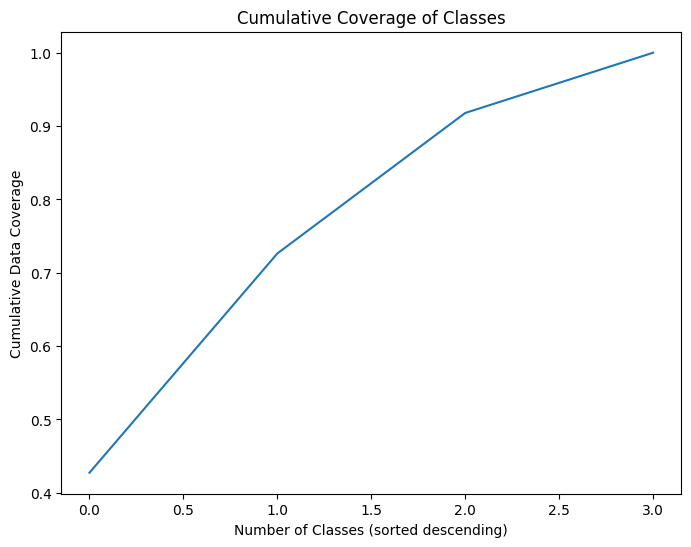

In [25]:
sorted_counts = label_counts.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum()

plt.figure(figsize=(8,6))
plt.plot(cumulative.values)
plt.xlabel("Number of Classes (sorted descending)")
plt.ylabel("Cumulative Data Coverage")
plt.title("Cumulative Coverage of Classes")
plt.show()

Cumulative Coverage: คลาสเพียง 2 อันดับแรก (cs.LG และ cs.CV) ครอบคลุมข้อมูลไปแล้วกว่า 70% ของทั้งหมด

**7.5.Distribution ของ "จำนวน label ต่อ sample"**

Label Cardinality: 1.5247446283902784
Label Density: 0.3811861570975696


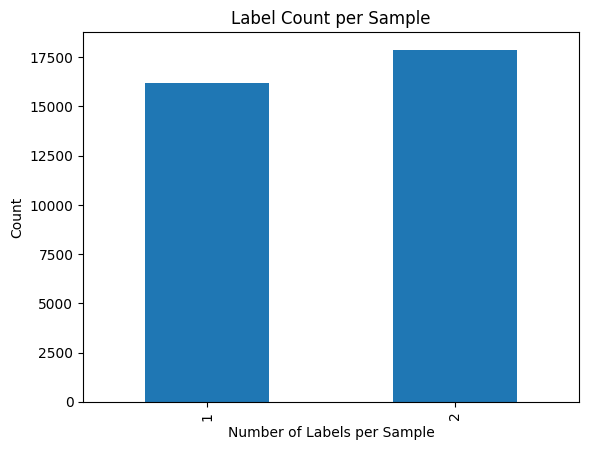

In [29]:
label_cardinality = df["clean_labels"].apply(len).mean()
label_density = label_cardinality / len(label_counts)

print("Label Cardinality:", label_cardinality)
print("Label Density:", label_density)

labels_per_sample = df["clean_labels"].apply(len)

plt.figure()
labels_per_sample.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of Labels per Sample")
plt.ylabel("Count")
plt.title("Label Count per Sample")
plt.show()

**7.6.Label Co-occurrence Matrix**

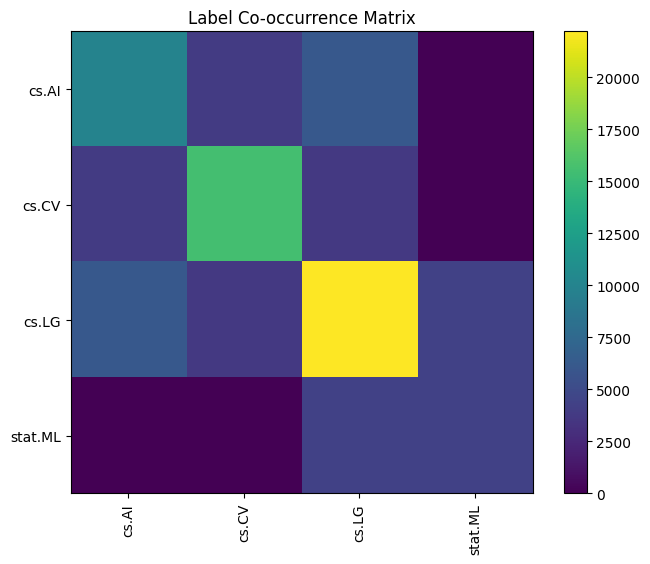

In [32]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
binary_matrix = mlb.fit_transform(df["clean_labels"])

co_occurrence = np.dot(binary_matrix.T, binary_matrix)

plt.figure(figsize=(8,6))
plt.imshow(co_occurrence)
plt.xticks(range(len(mlb.classes_)), mlb.classes_, rotation=90)
plt.yticks(range(len(mlb.classes_)), mlb.classes_)
plt.title("Label Co-occurrence Matrix")
plt.colorbar()
plt.show()

**จากกระบวณการข้อ 7.6** ทำให้เห็นว่า Label ไหนที่ชอบอยู่ด้วยกัน จากที่สังเกตุจะเห็นได้ว่า


*   cs.LG กับ cs.AI → ค่อนข้างสูง
*   cs.LG กับ stat.ML → ค่อนข้างสูง
*   cs.CV กับ cs.AI → ปานกลาง
*   stat.ML กับ cs.AI / cs.CV → แทบไม่มี








**7.7.Word Count and Text lenght**

        text_length    word_count
count  34068.000000  34068.000000
mean    1272.716567    179.023893
std      308.936011     43.696691
min       29.000000      5.000000
25%     1060.000000    149.000000
50%     1271.000000    178.000000
75%     1484.000000    208.000000
max     2479.000000    349.000000


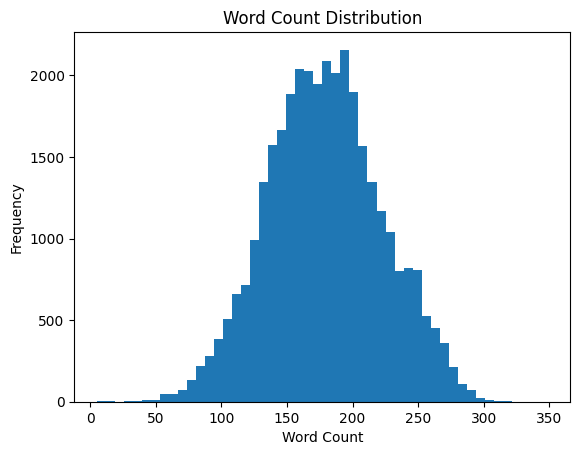

In [43]:
df['text_length'] = df['Abstracts'].apply(len)
df['word_count'] = df['Abstracts'].apply(lambda x: len(str(x).split()))

print(df[['text_length', 'word_count']].describe())

plt.figure()
plt.hist(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

**7.8.คำที่พบบ่อย (Top Words) และ Word Cloud**

In [46]:
from collections import Counter

all_words = " ".join(df['Abstracts'].astype(str)).split()
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('the', 290086), ('of', 172724), ('and', 170760), ('to', 148262), ('a', 136762), ('in', 93865), ('for', 69125), ('on', 62973), ('is', 62140), ('that', 59833), ('we', 59223), ('with', 47936), ('learning', 38283), ('this', 36704), ('as', 34820), ('by', 34602), ('We', 33373), ('are', 30844), ('from', 29312), ('an', 28153)]


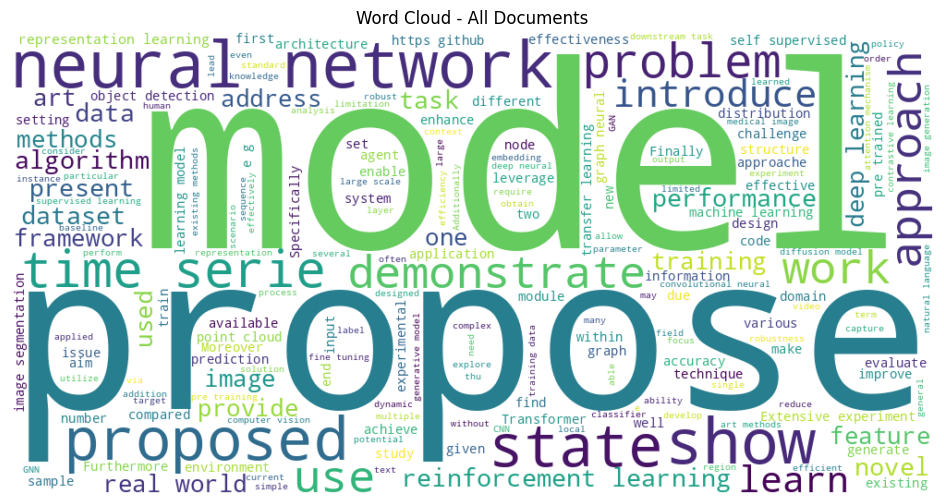

In [48]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# รวมข้อความทั้งหมด
all_text = " ".join(df["Abstracts"].astype(str))

# เพิ่ม stopwords เองได้
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["using", "based", "method", "results", "paper"])

# สร้าง word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=200
).generate(all_text)

# แสดงผล
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - All Documents")
plt.show()

**7.9.Hierarchical Distribution**

In [50]:
def extract_parent(labels):
    parents = [label.split(".")[0] for label in labels]
    return list(set(parents))  # เอา unique

df["parent_category"] = df["clean_labels"].apply(extract_parent)

cs      34068
stat     4266
Name: count, dtype: int64


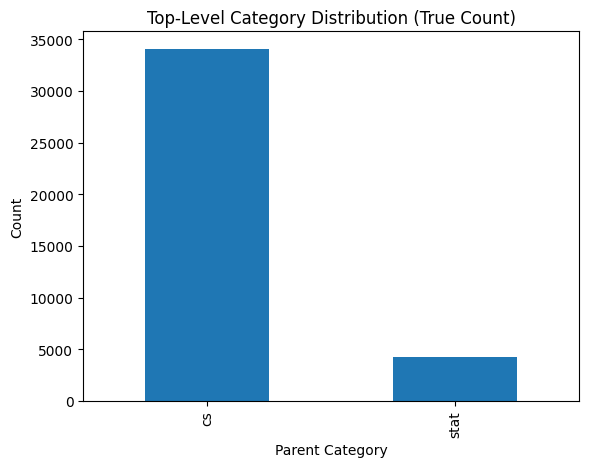

In [52]:
all_parents = []

for parents in df["parent_category"]:
    all_parents.extend(parents)

parent_counts = pd.Series(all_parents).value_counts()

print(parent_counts)

plt.figure()
parent_counts.plot(kind="bar")
plt.title("Top-Level Category Distribution (True Count)")
plt.xlabel("Parent Category")
plt.ylabel("Count")
plt.show()

จากกราฟพบว่าข้อมูลเป็นลักษณะ multi-label โดยแต่ละตัวอย่างมีฉลากเฉลี่ยประมาณ 1.52 label แสดงว่าส่วนใหญ่มี 1–2 labels และจำนวนตัวอย่างที่มี 2 label มีมากกว่า 1 label เล็กน้อย นอกจากนี้ค่า Label Density ≈ 0.38 บ่งบอกว่าจำนวนป้ายที่ถูกใช้จริงยังไม่หนาแน่นมากเมื่อเทียบกับจำนวนป้ายทั้งหมดในระบบ

**7.10.TF-IDF + PCA Visualization**

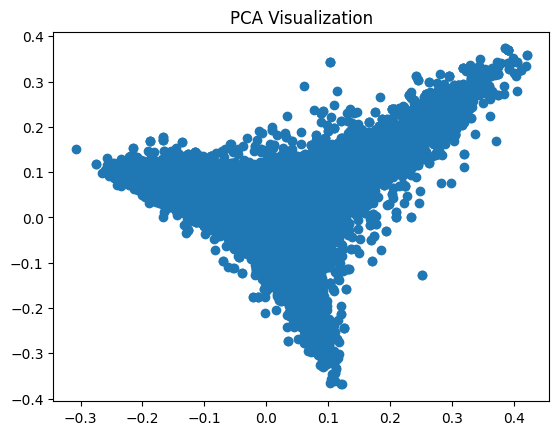

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Abstracts'])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.show()

จากกราฟ PCA เห็นว่าข้อมูลกระจาย และมีการรวมกลุ่มหนาแน่นบริเวณกึ่งกลาง แสดงว่าข้อมูลมีโครงสร้างบางอย่างแต่ยังไม่แยกคลัสเตอร์ชัดเจนใน 2 มิติแรก จุดส่วนใหญ่เกาะกลุ่มต่อเนื่องกันโดยไม่มีขอบเขตแบ่งที่ชัด ทำให้คาดว่าคลาสต่าง ๆ อาจซ้อนทับกันเมื่อมองผ่าน PCA เพียงสองแกนหลัก

# Answer Question 8 (Preprocessing)

In [65]:
import re

In [69]:
def clean_text(text):
    text = re.sub(r"\W+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stopwords]
    return " ".join(words)

เคลียคอลัมน์ที่ไม่ได้ใช้ เพราะเราจะใช้ Clean label แทน Categories เดิม

In [57]:
df.drop(columns=['categories'], inplace=True)

พิจารณาทำ Lower Case

In [63]:
df["Abstracts"] = df["Abstracts"].str.lower()

ลบสัญลักษณ์ที่ไม่เกี่ยวข้อง

In [67]:
df["Abstracts"] = df["Abstracts"].apply(clean_text)

ลบ Stopwords

In [70]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stopwords = set(ENGLISH_STOP_WORDS)


df["Abstracts"] = df["Abstracts"].apply(remove_stopwords)